# Physics-Informed Neural Networks (PINNs) for Chemical Reactor Modeling

This notebook demonstrates the application of **Physics-Informed Neural Networks (PINNs)** to solve coupled ordinary differential equations (ODEs) governing an irreversible exothermic reaction in a batch reactor. We compare two popular frameworks—**DeepXDE** and **PyTorch**—against a traditional numerical solver (SciPy's `solve_ivp`).

In this notebook, we will solve the first order reaction of an irreversible reaction of a species inside a batch reactor.

**Problem Statement**:
Consider an irreversible first order reaction of a species $A$ taking place in a batch reactor non-isothermally. The reaction is exothermic, releasing heat during the reaction. We are known with the initial concentration of the reactant $C_0$ and the initial temperature $T_0 = 350 K$. The reactor is cooled using a coolant which is at a temperature $T_{coolant} = 350 K$. We need to solve the governing differntial equations by training the neural network and see the decay of the reactant concentration with respect to time $t$.

The reaction:
$$A→R$$

The governing differential equation of this reaction is given by

$$\frac{dC}{dt} = -k(T) C, \qquad t \in [0, 10]$$

$$\frac{dT}{dt} = \frac{-\Delta H}{\rho C_p}.k(T)C - \frac{UA}{\rho C_p V}.(T-T_{coolant})$$
Here, the rate constant $k$ is a function of temperature and can be expressed as an Arrhenius Rate Expression

$$k=A_0 exp(\frac{-E}{RT})$$
where,
1. $A_0$ is the pre-exponential factor : $A_0 = 1 \times 10^8 s^{-1}$
2. $E$ is the activation function: $E = 50,000 J/mol$
3. $R$ is the universal gas constant: $R = 8.314 J/mol .K$
4. $T$ is the temperature
5. $\Delta H$ is the heat release (negative sign) : $\Delta H = -40,000 J/mol$
6. $\rho C_p$ is the heat capacity of the mixture : $\rho C_p = 4,000 J/L.K$
7. $\frac{UA}{\rho C_p V}$ is the cooling coefficient: $\frac{UA}{\rho C_p V} = 0.05 s^{-1}$

Initial Concentration $C_0 = 1 mol/L$

## 1. Environment Setup
We install the necessary libraries and set up the computational environment.

# **DeepXDE Implementation**

In [ ]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.9 MB/s eta 0:00:00


## 2. Implementation using DeepXDE
In this section, we define the geometry, PDE residuals, and initial conditions using the DeepXDE library.

In [ ]:
# Importing the libraries
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [ ]:
#  Defining the constants and parameters
A0 = 1e8    # Unit: s^-1
E = 50000   # Unit: J/mol
R = 8.314   # Unit: J/mol K
T0 = 350     # Unit: K
c0= 1       # Unit: mol/L
delH = -40000.0 # Unit: J/mol
rhocp = 4000.0  # Unit: J/L.K
cool_coef = 0.05 # Unit: s^-1
T_cool = 350 # Unit: K

In [ ]:
# Defining the specific rate expression
def k(T):
  return A0 * tf.exp(-E/(R*T))

In [ ]:
# Defining the computational domain
timedomain = dde.geometry.TimeDomain(0, 10)

In [ ]:
# Redefining the PDE with stricter safeguards for numerical stability
def pde(t, y):
    C = y[:, 0:1]
    T_scaled = y[:, 1:2]

    # Map T_scaled (expected around 3.5) back to T (Kelvin)
    # We use tf.clip_by_value to prevent extreme exponents in the Arrhenius term
    # 3.0 represents 300K, 5.0 represents 500K.
    T_safe_scaled = tf.clip_by_value(T_scaled, 2.0, 6.0)
    T = T_safe_scaled * 100

    dC_dt = dde.grad.jacobian(y, t, i=0, j=0)
    dTscaled_dt = dde.grad.jacobian(y, t, i=1, j=0)
    dT_dt = dTscaled_dt * 100

    # Arrhenius rate
    rate = k(T) * C

    f1 = dC_dt + rate
    # Balance the magnitude of the heat equation residual
    f2 = (dT_dt + (delH / rhocp) * rate + (cool_coef * (T - T_cool)))

    return [f1, f2]

In [ ]:
# Defining the initial conditions
def on_initial(t, on_boundary):
  return on_boundary and dde.utils.isclose(t[0], 0)

ic1 = dde.icbc.IC(timedomain, lambda t: c0, on_initial, component=0)
ic2 = dde.icbc.IC(timedomain, lambda t: T0/100, on_initial, component=1)

In [ ]:
# Defining the problem with updated ICs and scaling
data = dde.data.TimePDE(timedomain, pde, [ic1, ic2], num_domain = 300, num_boundary=2, num_test = 150)

In [ ]:
# Improving convergence by increasing iterations and using a multi-step optimizer approach
layer_size = [1] + [50] * 3 + [2]
activation = "tanh"
initializer = "Glorot uniform"

net = dde.nn.FNN(layer_size, activation, initializer)


model = dde.Model(data, net)

model.compile("adam", lr=0.001, loss_weights=[1, 0.01, 1, 1])
losshistory, train_state = model.train(iterations=10000)

Compiling model...
'compile' took 0.005042 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [2.39e-03, 5.48e-01, 1.00e+00, 1.22e+01]    [2.27e-03, 5.35e-01, 1.00e+00, 1.22e+01]    []  
1000      [1.70e-03, 2.16e-03, 1.13e-04, 5.78e-03]    [1.30e-03, 1.99e-03, 1.13e-04, 5.78e-03]    []  
2000      [4.90e-04, 2.42e-04, 8.21e-07, 7.63e-05]    [4.02e-04, 2.40e-04, 8.21e-07, 7.63e-05]    []  
3000      [2.26e-04, 7.30e-05, 1.32e-06, 2.97e-05]    [1.71e-04, 7.39e-05, 1.32e-06, 2.97e-05]    []  
4000      [1.81e-04, 6.11e-05, 5.65e-07, 6.48e-06]    [1.42e-04, 6.08e-05, 5.65e-07, 6.48e-06]    []  
5000      [2.96e-04, 7.37e-05, 2.52e-05, 7.66e-04]    [9.30e-05, 6.68e-05, 2.52e-05, 7.66e-04]    []  
6000      [1.27e-04, 3.64e-05, 2.70e-07, 1.32e-06]    [9.39e-05, 3.52e-05, 2.70e-07, 1.32e-06]    []  
7000      [1.04e-04, 2.54e-05, 2.83e-07, 1.78e-06]    [7.24e-05, 2.29e-05, 2.83e-07, 1.78e-06]    []  
8

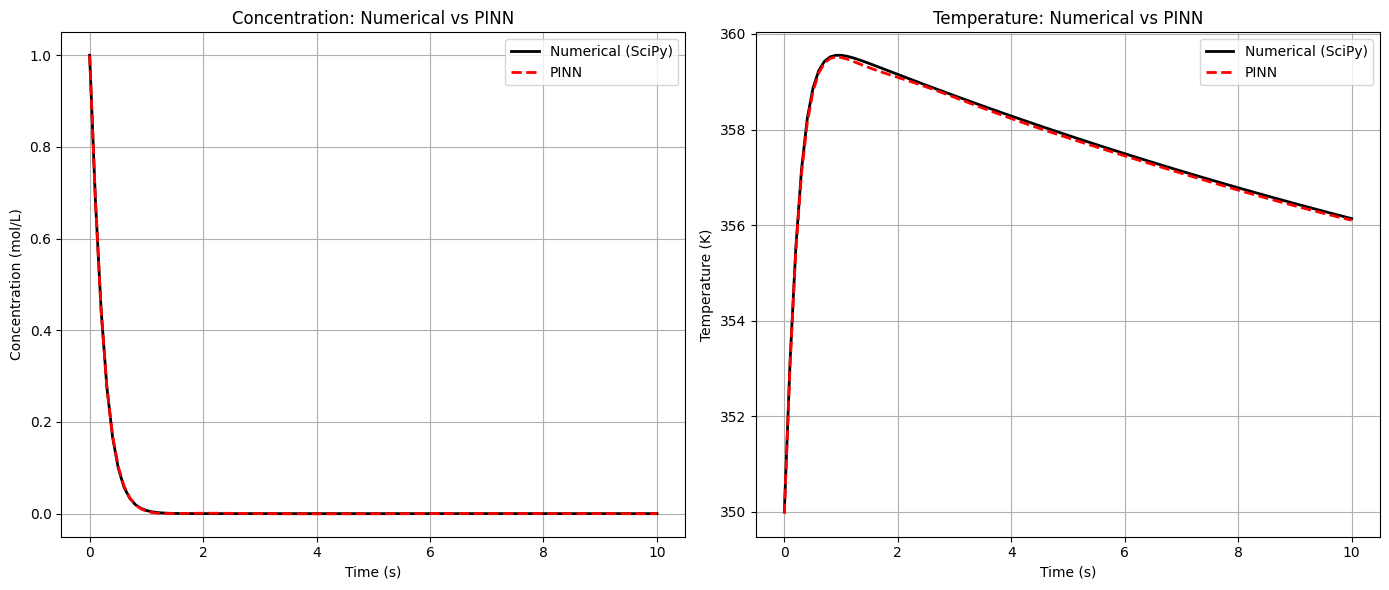

In [ ]:
from scipy.integrate import solve_ivp

# Numerical solver function for ODEs
def reaction_system(t, y):
    C, T = y
    # Arrhenius rate k = A0 * exp(-E / (R * T))
    current_k = A0 * np.exp(-E / (R * T))

    dCdt = -current_k * C
    dTdt = (-delH / rhocp) * (current_k * C) - cool_coef * (T - T_cool)

    return [dCdt, dTdt]

# Time span and initial conditions
t_span = (0, 10)
t_eval = np.linspace(0, 10, 100)
y0 = [c0, T0]

# Solve using RK45
sol = solve_ivp(reaction_system, t_span, y0, t_eval=t_eval, method='RK45')

# PINN predictions for the same time points
y_pinn = model.predict(t_eval.reshape(-1, 1))
C_pinn = y_pinn[:, 0]
T_pinn = y_pinn[:, 1] * 100

plt.figure(figsize=(14, 6))

# Plot Concentration Comparison
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0], 'k-', label='Numerical (SciPy)', linewidth=2)
plt.plot(t_eval, C_pinn, 'r--', label='PINN', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Concentration: Numerical vs PINN')
plt.legend()
plt.grid(True)

# Plot Temperature Comparison
plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[1], 'k-', label='Numerical (SciPy)', linewidth=2)
plt.plot(t_eval, T_pinn, 'r--', label='PINN', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (K)')
plt.title('Temperature: Numerical vs PINN')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Implementation using Pure PyTorch
To demonstrate flexibility, we implement a custom PINN training loop in PyTorch, focusing on manual gradient calculation and loss weighting.

When two coupled ODEs have residuals of very different magnitudes, never scale the residual inside the PDE function. Scale it through loss_weights at compile time. Scaling inside the PDE hides the imbalance from the developer and can silently suppress physically important terms — especially at late times when one driving term has nearly vanished.

# **Pytorch Implementation**

In [ ]:
# importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#  Defining the constants and parameters
A0 = 1e8    # Unit: s^-1
E = 50000   # Unit: J/mol
R = 8.314   # Unit: J/mol K
T0 = 350     # Unit: K
c0= 1       # Unit: mol/L
delH = -40000.0 # Unit: J/mol
rhocp = 4000.0  # Unit: J/L.K
cool_coef = 0.05 # Unit: s^-1
T_cool = 350 # Unit: K

In [ ]:
# Defining the specific rate expression
def k(T):
  return A0 * torch.exp(-E/(R*T))

In [ ]:
# Defining the neural network
class Net(nn.Module):

  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(1, 50)
    self.fc2 = nn.Linear(50, 50)
    self.fc3 = nn.Linear(50, 50)
    self.fc4 = nn.Linear(50, 2)

  def forward(self, t):
    a1 = F.tanh(self.fc1(t))
    a2 = F.tanh(self.fc2(a1))
    a3 = F.tanh(self.fc3(a2))
    output = self.fc4(a3)
    return output
net = Net()
print(net)

Net(
  (fc1): Linear(in_features=1, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=50, bias=True)
  (fc4): Linear(in_features=50, out_features=2, bias=True)
)


In [ ]:
def pde(net, t):
    pred = net(t)
    C = pred[:, 0:1]
    T_scaled = pred[:, 1:2]

    T = T_scaled * 100.0

    # Time derivatives — unclamped, gradient path intact
    dC_dt = torch.autograd.grad(
        C, t,
        grad_outputs=torch.ones_like(C),
        create_graph=True,
        retain_graph=True
    )[0]

    dT_dt_scaled = torch.autograd.grad(
        T_scaled, t,
        grad_outputs=torch.ones_like(T_scaled),
        create_graph=True,
        retain_graph=True
    )[0]
    dT_dt = dT_dt_scaled * 100.0

    # Clamp T to physical range ONLY for Arrhenius calculation
    # This prevents overflow when network predicts unphysical T during early training
    T_phys = torch.clamp(T, 100.0, 1000.0)
    rate = A0 * torch.exp(-E / (R * T_phys)) * C

    # Residuals — physics
    f1 = dC_dt + rate
    f2 = dT_dt + (delH / rhocp) * rate + cool_coef * (T - T_cool)

    return f1, f2

In [ ]:
def compute_loss(net, t, t_ic, C_ic, T_ic_scaled):
    f1, f2 = pde(net, t)

    loss_pde1 = torch.mean(f1 ** 2)
    loss_pde2 = torch.mean(f2 ** 2) * 0.01

    pred_ic = net(t_ic)
    loss_ic1 = torch.mean((pred_ic[:, 0] - C_ic) ** 2)
    loss_ic2 = torch.mean((pred_ic[:, 1] - T_ic_scaled) ** 2)

    # Weight ICs more strongly — critical for stiff systems
    loss = loss_pde1 + loss_pde2 + 100.0 * loss_ic1 + 100.0 * loss_ic2

    return loss, (loss_pde1 + loss_pde2), (loss_ic1 + loss_ic2)

In [ ]:
# Collocation points — clustered toward early time where dynamics are fast
t_uniform = torch.linspace(0, 10, 400).reshape(-1, 1)
t_early   = torch.linspace(0, 1.5, 100).reshape(-1, 1)
t = torch.cat([t_uniform, t_early], dim=0).requires_grad_(True)

# IC points
t_ic       = torch.zeros(20, 1)    # no requires_grad needed here
C_ic       = torch.ones(20) * c0
T_ic_scaled = torch.ones(20) * (T0 / 100.0)

In [ ]:
torch.manual_seed(42)
net = Net()
optimizer = optim.Adam(net.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9997)

loss_history = []

for epoch in range(20001):
    optimizer.zero_grad()

    # Zero gradient on t — prevents accumulation across epochs
    if t.grad is not None:
        t.grad.zero_()

    loss, l_pde, l_ic = compute_loss(net, t, t_ic, C_ic, T_ic_scaled)

    if torch.isnan(loss):
        print(f"NaN at epoch {epoch}")
        break

    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    if epoch % 2000 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4e} | "
              f"PDE: {l_pde.item():.4e} | IC: {l_ic.item():.4e} | LR: {lr:.6f}")

Epoch     0 | Loss: 1.3079e+03 | PDE: 4.0440e+00 | IC: 1.3039e+01 | LR: 0.001000
Epoch  2000 | Loss: 2.3293e-03 | PDE: 2.3230e-03 | IC: 6.2192e-08 | LR: 0.000549
Epoch  4000 | Loss: 1.1497e-03 | PDE: 1.1494e-03 | IC: 2.6900e-09 | LR: 0.000301
Epoch  6000 | Loss: 7.9016e-04 | PDE: 7.8997e-04 | IC: 1.9278e-09 | LR: 0.000165
Epoch  8000 | Loss: 5.0648e-04 | PDE: 5.0633e-04 | IC: 1.4990e-09 | LR: 0.000091
Epoch 10000 | Loss: 2.8867e-04 | PDE: 2.8857e-04 | IC: 9.1392e-10 | LR: 0.000050
Epoch 12000 | Loss: 1.6178e-04 | PDE: 1.6174e-04 | IC: 3.6889e-10 | LR: 0.000027
Epoch 14000 | Loss: 9.7010e-05 | PDE: 9.6986e-05 | IC: 2.4569e-10 | LR: 0.000015
Epoch 16000 | Loss: 6.3858e-05 | PDE: 6.3846e-05 | IC: 1.1471e-10 | LR: 0.000008
Epoch 18000 | Loss: 4.4817e-05 | PDE: 4.4811e-05 | IC: 6.7963e-11 | LR: 0.000005
Epoch 20000 | Loss: 3.2910e-05 | PDE: 3.2854e-05 | IC: 5.6252e-10 | LR: 0.000002


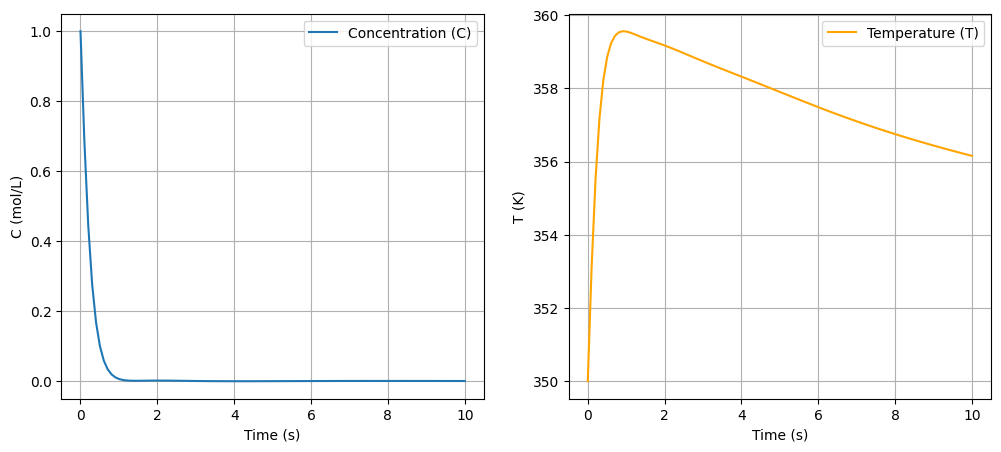

In [ ]:
# Visualizing PyTorch Results with un-scaling
with torch.no_grad():
    t_plot = torch.linspace(0, 10, 100).reshape(-1, 1)
    pred = net(t_plot).numpy()
    C_pred = pred[:, 0]
    T_pred = pred[:, 1] * 100 # Un-scale to Kelvin

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_plot.numpy(), C_pred, label='Concentration (C)')
plt.xlabel('Time (s)')
plt.ylabel('C (mol/L)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_plot.numpy(), T_pred, label='Temperature (T)', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('T (K)')
plt.legend()
plt.grid(True)
plt.show()

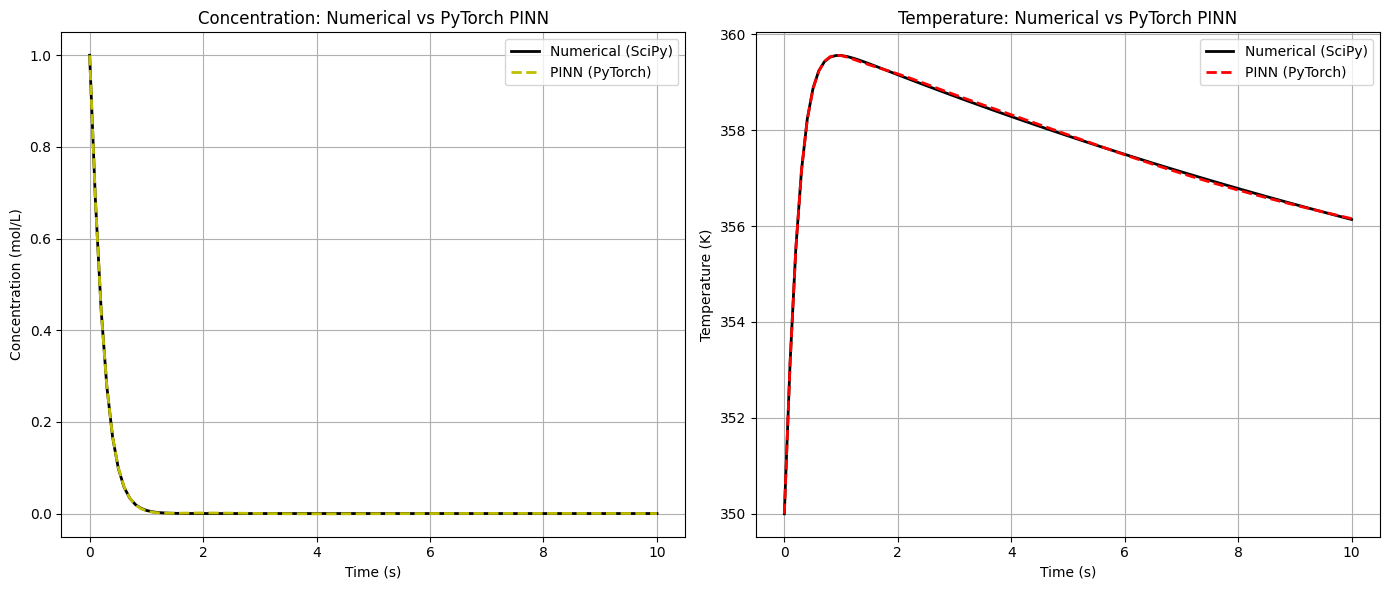

In [ ]:
# Comparing PyTorch Results with Numerical Solution
import torch
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Ensure numerical solution is available
def reaction_system(t, y):
    C, T = y
    current_k = A0 * np.exp(-E / (R * T))
    dCdt = -current_k * C
    dTdt = (-delH / rhocp) * (current_k * C) - cool_coef * (T - T_cool)
    return [dCdt, dTdt]

t_span = (0, 10)
t_eval_pts = np.linspace(0, 10, 100)
sol_ref = solve_ivp(reaction_system, t_span, [c0, T0], t_eval=t_eval_pts, method='RK45')

# 2. Get PINN predictions for the same time points
with torch.no_grad():
    t_eval_torch = torch.tensor(t_eval_pts, dtype=torch.float32).reshape(-1, 1)
    pred_torch = net(t_eval_torch).numpy()
    C_pinn_torch = pred_torch[:, 0]
    T_pinn_torch = pred_torch[:, 1] * 100  # Un-scaling to Kelvin

# 3. Plotting Comparison
plt.figure(figsize=(14, 6))

# Plot Concentration Comparison
plt.subplot(1, 2, 1)
plt.plot(sol_ref.t, sol_ref.y[0], 'k-', label='Numerical (SciPy)', linewidth=2)
plt.plot(t_eval_pts, C_pinn_torch, 'y--', label='PINN (PyTorch)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.title('Concentration: Numerical vs PyTorch PINN')
plt.legend()
plt.grid(True)

# Plot Temperature Comparison
plt.subplot(1, 2, 2)
plt.plot(sol_ref.t, sol_ref.y[1], 'k-', label='Numerical (SciPy)', linewidth=2)
plt.plot(t_eval_pts, T_pinn_torch, 'r--', label='PINN (PyTorch)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (K)')
plt.title('Temperature: Numerical vs PyTorch PINN')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Conclusion and Results Summary

### Key Observations:
1. **Accuracy**: Both DeepXDE and PyTorch implementations successfully capture the concentration decay and the temperature spike (exothermic peak).
2. **Numerical Stability**: Scaling the temperature by a factor of 100 and using loss weighting was critical to handle the stiffness of the Arrhenius term.
3. **Comparison**: The PINN results align closely with the SciPy RK45 numerical solution, validating the neural network's ability to learn the underlying physics of the chemical system.